# Dome Flow Estimation from Louvers, Shutter, and Anemometers

This notebook builds a bulk-flow estimate for the Vera C. Rubin Observatory dome on Cerro Pachón.

## Ventilation System Overview

**Aperture shutter** — bi-parting door at the telescope pointing direction (0° reference):
- Without Light Wind Screen (LWS): ~200 m² effective open area
- With LWS installed: ~119 m² (110 m² optical gap + 90 m² panel area × 10% permeability)
- Contribution follows cos(θ) where θ = wind angle relative to shutter; contributes only within ±90° of the pointing direction

**Louvered Light Baffling Vents (LLBVs)** — 34 motorized louver assemblies in 12 bays spanning the full dome wall:
- 28 operational nighttime louvers from 53.1° to 306.9° (clockwise from shutter), ~232 m² total effective area
- 6 F/G bays at 180° (Rear Access Door, RAD) excluded from nighttime operations — always closed, not yet commissioned
- Sinusoidal baffle profile: ~80% effective airflow area at full-open; `effective_area_m2 = gross_area_m2 × 0.80`
- Individual effective areas range from 4.03 m² (Type 7, small 2-row) to 10.40 m² (Type 1, full 3-row)
- DCS controls each louver independently; upwind louvers act as inlets, downwind as exhaust to create cross-flow
- CFD target: ~2.5 m/s uniform interior flow

**Current commissioning configuration** opens the bottom row (row 1) of all non-RAD bays plus E2 and H2:
- Louvers: A1, B1, C1, D1, E1, E2, H1, H2, I1, L1, M1, N1 (~110 m² effective)

**Data sources:**
- Outside wind: `lsst.sal.ESS.airFlow` index 301
- Mount anemometers: `lsst.sal.ESS.airTurbulence` indices 110 and 123–126
- Dome azimuth: `lsst.sal.MTDome.azimuth`
- Shutter opening: `lsst.sal.MTDome.apertureShutter`
- Louver geometry: `louver_map.csv` (34 louvers with azimuths, effective areas, RAD flags)

## Model Summary

For each timestamp, the notebook computes:

- Windward louver area: the sum of louver areas facing the incoming wind
- Leeward louver area: the sum of louver areas facing away from the incoming wind
- Shutter area contribution from the measured shutter opening fraction
- Effective through area: `min(A_in, A_out)` as a bottleneck approximation
- Outside driver: `U_out * A_eff`
- Inside flow proxy: mean or median mount-anemometer speed

If you also provide an internal reference area, the notebook converts the inside proxy to an estimated volumetric flow and fits an effective discharge coefficient.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from pathlib import Path
from IPython.display import display

from astropy.time import Time, TimeDelta
import astropy.units as u

from lsst_efd_client import EfdClient

%matplotlib inline

In [18]:
EFD_ALIAS = "usdf_efd"

t_end = Time("2026-04-01T05:00:00", scale="utc")
t_start = t_end - TimeDelta(25 * u.day)

RESAMPLE_RULE = "30s"
MIN_INSIDE_SENSORS = 3

flow_topic = "lsst.sal.ESS.airFlow"
turb_topic = "lsst.sal.ESS.airTurbulence"
dome_topic = "lsst.sal.MTDome.azimuth"
shutter_topic = "lsst.sal.MTDome.apertureShutter"

weather_index = 301
speed_field = "speedMagnitude"
outside_speed_field = "speed"
outside_direction_field = "direction"
dome_azimuth_field = "positionActual"
shutter_fields = ["positionActual0", "positionActual1"]

ess_sensors = {
    110: "TMA Platform",
    123: "Top Ring -X/-Y",
    124: "Top Ring +X/-Y",
    125: "Top Ring +X/+Y",
    126: "Top Ring -X/+Y",
}

speed_clip = {
    110: None,
    123: 8.6,
    124: 8.6,
    125: 8.6,
    126: 8.6,
}

# ── Shutter geometry ──────────────────────────────────────────────────────────
# Without LWS: ~200 m² full open.
# With LWS installed: ~119 m² (110 m² optical gap + 90 m² panel area × 10% air permeability).
SHUTTER_FULL_OPEN_AREA_M2_NO_LWS   = 200.0
SHUTTER_FULL_OPEN_AREA_M2_WITH_LWS = 119.0
SHUTTER_FULL_OPEN_AREA_M2 = SHUTTER_FULL_OPEN_AREA_M2_NO_LWS  # switch to _WITH_LWS when LWS is installed

SHUTTER_AZIMUTH_OFFSET_DEG = 0.0

# ── Internal flow calibration (set when flow measurements are available) ──────
INTERNAL_REFERENCE_AREA_M2 = np.nan
INITIAL_DISCHARGE_COEFFICIENT = 1.0

print(f"Start: {t_start.iso}")
print(f"End:   {t_end.iso}")
print(f"Resample rule: {RESAMPLE_RULE}")
print(f"Shutter area: {SHUTTER_FULL_OPEN_AREA_M2:.0f} m²  (no-LWS={SHUTTER_FULL_OPEN_AREA_M2_NO_LWS:.0f}, with-LWS={SHUTTER_FULL_OPEN_AREA_M2_WITH_LWS:.0f})")

Start: 2026-03-07 05:00:00.000
End:   2026-04-01 05:00:00.000
Resample rule: 30s
Shutter area: 200 m²  (no-LWS=200, with-LWS=119)


## Louver Geometry Input

The notebook looks for a file named `louver_map.csv` in the working directory. If it does not exist, it creates a 34-row template.

Required columns:

- `louver_id`: label such as `L01`
- `azimuth_dome_deg`: louver outward normal in dome coordinates, degrees
- `full_open_area_m2`: full-open geometric area in square meters
- `open_fraction`: static opening fraction between 0 and 1 for the analysis window

If only some louvers are open, set the others to `0.0`.

In [19]:
louver_map_path = Path("louver_map.csv")

if louver_map_path.exists():
    louver_map = pd.read_csv(louver_map_path)
else:
    louver_map = pd.DataFrame({
        "louver_id": [f"L{i:02d}" for i in range(1, 35)],
        "louver_type": [np.nan] * 34,
        "gross_area_m2": [np.nan] * 34,
        "effective_area_m2": [np.nan] * 34,   # gross × 0.80 (sinusoidal baffle factor)
        "azimuth_dome_deg": [np.nan] * 34,
        "is_rad": [False] * 34,                # True for F/G RAD bays (180°, excluded from nighttime ops)
        "open_fraction": [1.0] * 34,
    })

# Ensure boolean type for is_rad (CSV may read it as str)
louver_map["is_rad"] = louver_map["is_rad"].astype(bool)

nighttime_louvers = louver_map[~louver_map["is_rad"]]
commissioning_open = louver_map[louver_map["open_fraction"] > 0]

display(louver_map)
print()
print(f"Total louvers: {len(louver_map)}  |  Nighttime operational (non-RAD): {(~louver_map['is_rad']).sum()}")
print(f"Open in current config: {(louver_map['open_fraction'] > 0).sum()} louvers")
print(f"  ids: {', '.join(commissioning_open['louver_id'].tolist())}")
print(f"  effective louver area (open only): {(louver_map['effective_area_m2'] * louver_map['open_fraction']).sum():.1f} m²")
print(f"  gross louver area (open only):     {(louver_map['gross_area_m2'] * louver_map['open_fraction']).sum():.1f} m²")
print(f"Total nighttime effective area (all non-RAD fully open): {nighttime_louvers['effective_area_m2'].sum():.1f} m²")

,index,louver_id,louver_type,gross_area_m2,effective_area_m2,azimuth_dome_deg,is_rad,open_fraction
0,0,A1,1,13.00,10.40,53.10,False,0.0
1,1,A2,7,5.04,4.03,53.10,False,0.0
2,2,B1,1,13.00,10.40,67.50,False,1.0
3,3,B2,1,13.00,10.40,67.50,False,0.0
4,4,B3,4,9.03,7.22,67.50,False,0.0
5,5,C1,1,13.00,10.40,95.50,False,0.0
6,6,C2,1,13.00,10.40,95.50,False,0.0
7,7,C3,1,13.00,10.40,95.50,False,0.0
8,8,D1,2,9.87,7.90,120.75,False,0.0
9,9,D2,2,9.87,7.90,120.75,False,0.0



Total louvers: 34  |  Nighttime operational (non-RAD): 28
Open in current config: 6 louvers
  ids: B1, E1, E2, H1, H2, M1
  effective louver area (open only): 52.4 m²
  gross louver area (open only):     65.5 m²
Total nighttime effective area (all non-RAD fully open): 236.8 m²


In [20]:
def wrap180(angle_deg):
    angle_deg = np.asarray(angle_deg, dtype=float)
    return (angle_deg + 180.0) % 360.0 - 180.0


def circular_mean_deg(values):
    values = pd.Series(values).dropna().astype(float)
    if values.empty:
        return np.nan
    radians = np.deg2rad(values.to_numpy())
    return np.mod(np.rad2deg(np.arctan2(np.sin(radians).mean(), np.cos(radians).mean())), 360.0)


def validate_geometry(louver_map, shutter_full_open_area_m2):
    required_cols = ["louver_id", "effective_area_m2", "azimuth_dome_deg", "open_fraction", "is_rad"]
    missing_cols = [col for col in required_cols if col not in louver_map.columns]
    if missing_cols:
        raise ValueError(f"louver_map is missing columns: {missing_cols}")

    if len(louver_map) != 34:
        raise ValueError(f"Expected 34 louvers, found {len(louver_map)}")

    if louver_map[["effective_area_m2", "azimuth_dome_deg", "open_fraction"]].isna().any().any():
        raise ValueError(
            "Fill effective_area_m2, azimuth_dome_deg, and open_fraction for all 34 louvers."
        )

    if (louver_map["open_fraction"] < 0).any() or (louver_map["open_fraction"] > 1).any():
        raise ValueError("open_fraction must be between 0 and 1")

    if not np.isfinite(shutter_full_open_area_m2) or shutter_full_open_area_m2 <= 0:
        raise ValueError("Set SHUTTER_FULL_OPEN_AREA_M2 to the full-open shutter aperture area in m^2")

    n_rad = louver_map["is_rad"].sum()
    if n_rad != 6:
        print(f"Warning: expected 6 RAD louvers (F/G at 180°), found {n_rad}")


def resample_direction(series, rule):
    return series.resample(rule).apply(circular_mean_deg)


def prepare_inside_sensor(df, sensor_idx, label, clip_threshold, rule):
    speed = df[speed_field].astype(float).copy()
    if clip_threshold is not None:
        speed = speed.where(speed < clip_threshold)
    speed = speed.resample(rule).mean()
    speed.name = f"{sensor_idx}_{label}"
    return speed


def compute_effective_areas(frame, louver_map, shutter_full_open_area_m2, shutter_azimuth_offset_deg):
    """Compute per-timestamp windward, leeward, shutter, and effective through areas.

    Uses effective_area_m2 from louver_map (= gross × 0.80 sinusoidal baffle factor).
    RAD louvers (is_rad=True) are excluded by their open_fraction=0 in the CSV.
    """
    louver_angles = louver_map["azimuth_dome_deg"].to_numpy(dtype=float)
    louver_areas = (
        louver_map["effective_area_m2"].to_numpy(dtype=float)
        * louver_map["open_fraction"].to_numpy(dtype=float)
    )

    windward_area = np.full(len(frame), np.nan)
    leeward_area = np.full(len(frame), np.nan)
    shutter_area = np.full(len(frame), np.nan)
    effective_through_area = np.full(len(frame), np.nan)

    wind_dir = frame["outside_wind_dir_deg"].to_numpy(dtype=float)
    dome_az = frame["dome_azimuth_deg"].to_numpy(dtype=float)
    shutter_frac = frame["shutter_open_fraction"].to_numpy(dtype=float)

    for i in range(len(frame)):
        if not np.isfinite(wind_dir[i]) or not np.isfinite(dome_az[i]) or not np.isfinite(shutter_frac[i]):
            continue

        global_louver_angles = dome_az[i] + louver_angles
        rel = wrap180(wind_dir[i] - global_louver_angles)
        projection = np.cos(np.deg2rad(rel))

        a_in_louver = np.sum(louver_areas * np.clip(projection, 0, None))
        a_out_louver = np.sum(louver_areas * np.clip(-projection, 0, None))

        shutter_angle = dome_az[i] + shutter_azimuth_offset_deg
        shutter_rel = wrap180(wind_dir[i] - shutter_angle)
        shutter_proj = np.cos(np.deg2rad(shutter_rel))
        a_shutter = shutter_full_open_area_m2 * shutter_frac[i]

        a_in_shutter = a_shutter * max(shutter_proj, 0.0)
        a_out_shutter = a_shutter * max(-shutter_proj, 0.0)

        windward_area[i] = a_in_louver + a_in_shutter
        leeward_area[i] = a_out_louver + a_out_shutter
        shutter_area[i] = a_shutter
        effective_through_area[i] = min(windward_area[i], leeward_area[i])

    result = frame.copy()
    result["windward_open_area_m2"] = windward_area
    result["leeward_open_area_m2"] = leeward_area
    result["shutter_open_area_m2"] = shutter_area
    result["effective_through_area_m2"] = effective_through_area
    result["outside_driver_m3s_cd1"] = result["outside_wind_speed_mps"] * result["effective_through_area_m2"]
    return result

In [21]:
validate_geometry(louver_map, SHUTTER_FULL_OPEN_AREA_M2)
print("Geometry validation passed.")
open_eff = np.sum(louver_map["effective_area_m2"] * louver_map["open_fraction"])
print(f"Effective louver area at current open fractions: {open_eff:.1f} m²")
print(f"Shutter area (active config): {SHUTTER_FULL_OPEN_AREA_M2:.0f} m²")

Geometry validation passed.
Effective louver area at current open fractions: 52.4 m²
Shutter area (active config): 200 m²


In [22]:
client = EfdClient(EFD_ALIAS)
print(f"Connected to {EFD_ALIAS}")

df_weather = await client.select_time_series(
    flow_topic,
    fields=[outside_speed_field, outside_direction_field],
    start=t_start,
    end=t_end,
    index=weather_index,
)

df_dome = await client.select_time_series(
    dome_topic,
    fields=[dome_azimuth_field],
    start=t_start,
    end=t_end,
)

df_shutter = await client.select_time_series(
    shutter_topic,
    fields=shutter_fields,
    start=t_start,
    end=t_end,
)

inside_raw = {}
for sensor_idx, label in ess_sensors.items():
    inside_raw[sensor_idx] = await client.select_time_series(
        turb_topic,
        fields=[speed_field],
        start=t_start,
        end=t_end,
        index=sensor_idx,
    )

print(f"Weather rows: {len(df_weather)}")
print(f"Dome azimuth rows: {len(df_dome)}")
print(f"Shutter rows: {len(df_shutter)}")
for sensor_idx, label in ess_sensors.items():
    print(f"Inside sensor {sensor_idx:3d} {label:16s}: {len(inside_raw[sensor_idx])} rows")

Connected to usdf_efd
Weather rows: 1687538
Dome azimuth rows: 2570513
Shutter rows: 1027743
Inside sensor 110 TMA Platform    : 431513 rows
Inside sensor 123 Top Ring -X/-Y  : 431532 rows
Inside sensor 124 Top Ring +X/-Y  : 431591 rows
Inside sensor 125 Top Ring +X/+Y  : 429015 rows
Inside sensor 126 Top Ring -X/+Y  : 431545 rows


In [23]:
weather_aligned = pd.DataFrame({
    "outside_wind_speed_mps": df_weather[outside_speed_field].astype(float).resample(RESAMPLE_RULE).mean(),
    "outside_wind_dir_deg": resample_direction(df_weather[outside_direction_field], RESAMPLE_RULE),
})

dome_aligned = pd.DataFrame({
    "dome_azimuth_deg": resample_direction(df_dome[dome_azimuth_field], RESAMPLE_RULE),
})

shutter_aligned = df_shutter[shutter_fields].astype(float).resample(RESAMPLE_RULE).mean().rename(
    columns={
        "positionActual0": "shutter_left_pct",
        "positionActual1": "shutter_right_pct",
    }
)
shutter_aligned["shutter_open_fraction"] = (
    0.5 * (shutter_aligned["shutter_left_pct"] + shutter_aligned["shutter_right_pct"]) / 100.0
)

inside_series = []
for sensor_idx, label in ess_sensors.items():
    sensor_series = prepare_inside_sensor(
        inside_raw[sensor_idx],
        sensor_idx=sensor_idx,
        label=label.replace(" ", "_"),
        clip_threshold=speed_clip[sensor_idx],
        rule=RESAMPLE_RULE,
    )
    inside_series.append(sensor_series)

inside_aligned = pd.concat(inside_series, axis=1)
inside_aligned["inside_speed_mean_mps"] = inside_aligned.mean(axis=1, skipna=True)
inside_aligned["inside_speed_median_mps"] = inside_aligned.median(axis=1, skipna=True)
inside_aligned["inside_sensor_count"] = inside_aligned.notna().sum(axis=1)

model_df = pd.concat([weather_aligned, dome_aligned, shutter_aligned, inside_aligned], axis=1)
model_df = model_df.sort_index()
model_df = model_df[model_df["inside_sensor_count"] >= MIN_INSIDE_SENSORS].copy()

model_df = compute_effective_areas(
    model_df,
    louver_map=louver_map,
    shutter_full_open_area_m2=SHUTTER_FULL_OPEN_AREA_M2,
    shutter_azimuth_offset_deg=SHUTTER_AZIMUTH_OFFSET_DEG,
)

model_df["inside_flow_proxy_m3s"] = model_df["inside_speed_mean_mps"] * INTERNAL_REFERENCE_AREA_M2
model_df["outside_flow_initial_m3s"] = INITIAL_DISCHARGE_COEFFICIENT * model_df["outside_driver_m3s_cd1"]

print(f"Aligned samples after sensor-count filter: {len(model_df)}")
display(model_df.head())

Aligned samples after sensor-count filter: 71998


,outside_wind_speed_mps,outside_wind_dir_deg,dome_azimuth_deg,shutter_left_pct,shutter_right_pct,shutter_open_fraction,110_TMA_Platform,123_Top_Ring_-X/-Y,124_Top_Ring_+X/-Y,125_Top_Ring_+X/+Y,...,inside_speed_mean_mps,inside_speed_median_mps,inside_sensor_count,windward_open_area_m2,leeward_open_area_m2,shutter_open_area_m2,effective_through_area_m2,outside_driver_m3s_cd1,inside_flow_proxy_m3s,outside_flow_initial_m3s
2026-03-07 05:00:00+00:00,1.885565,21.127879,328.075989,100.040001,100.040001,1.0004,1.342393,0.202097,0.392148,0.147654,...,0.462445,0.310041,7,136.333365,20.994154,200.080002,20.994154,39.585847,NaN,39.585847
2026-03-07 05:00:30+00:00,1.800050,19.435000,328.075989,100.040001,100.040001,1.0004,1.632660,0.233944,0.312052,0.202825,...,0.529398,0.288781,7,140.489123,20.670013,200.080002,20.670013,37.207057,NaN,37.207057
2026-03-07 05:01:00+00:00,1.751400,19.327391,328.075989,100.040001,100.040001,1.0004,1.288509,0.217991,0.315769,0.168709,...,0.455218,0.300441,7,140.749179,20.648796,200.080002,20.648796,36.164301,NaN,36.164301
2026-03-07 05:01:30+00:00,1.782675,19.129167,328.075989,100.040001,100.040001,1.0004,1.064776,0.216584,0.516975,0.271129,...,0.479604,0.404081,7,141.226922,20.609521,200.080002,20.609521,36.740078,NaN,36.740078
2026-03-07 05:02:00+00:00,1.907322,19.189999,328.075989,100.040001,100.040001,1.0004,0.937078,0.297136,0.399961,0.178327,...,0.405644,0.348548,7,141.080488,20.621600,200.080002,20.621600,39.332027,NaN,39.332027


In [24]:
fit_df = model_df.dropna(
    subset=["outside_wind_speed_mps", "effective_through_area_m2", "inside_speed_mean_mps"]
).copy()
fit_df = fit_df[fit_df["effective_through_area_m2"] > 0].copy()

x = fit_df["outside_driver_m3s_cd1"].to_numpy(dtype=float)
y_speed = fit_df["inside_speed_mean_mps"].to_numpy(dtype=float)

speed_gain = np.dot(x, y_speed) / np.dot(x, x)
fit_df["inside_speed_fit_mps"] = speed_gain * fit_df["outside_driver_m3s_cd1"]
speed_corr = np.corrcoef(x, y_speed)[0, 1] if len(fit_df) > 1 else np.nan

print(f"Samples used for fit: {len(fit_df)}")
print(f"Best-fit speed gain [m/s per (m^3/s at Cd=1)]: {speed_gain:.6f}")
print(f"Correlation between inside speed and outside driver: {speed_corr:.3f}")

if np.isfinite(INTERNAL_REFERENCE_AREA_M2) and INTERNAL_REFERENCE_AREA_M2 > 0:
    y_flow = fit_df["inside_flow_proxy_m3s"].to_numpy(dtype=float)
    fitted_cd = np.dot(x, y_flow) / np.dot(x, x)
    fit_df["outside_flow_fit_m3s"] = fitted_cd * fit_df["outside_driver_m3s_cd1"]
    flow_corr = np.corrcoef(x, y_flow)[0, 1] if len(fit_df) > 1 else np.nan
    print(f"Fitted discharge coefficient: {fitted_cd:.4f}")
    print(f"Correlation in flow units: {flow_corr:.3f}")
else:
    fitted_cd = np.nan
    print("INTERNAL_REFERENCE_AREA_M2 is not set, so the notebook fits only a speed gain and not an absolute flow coefficient.")

Samples used for fit: 49307
Best-fit speed gain [m/s per (m^3/s at Cd=1)]: 0.006477
Correlation between inside speed and outside driver: 0.176
INTERNAL_REFERENCE_AREA_M2 is not set, so the notebook fits only a speed gain and not an absolute flow coefficient.


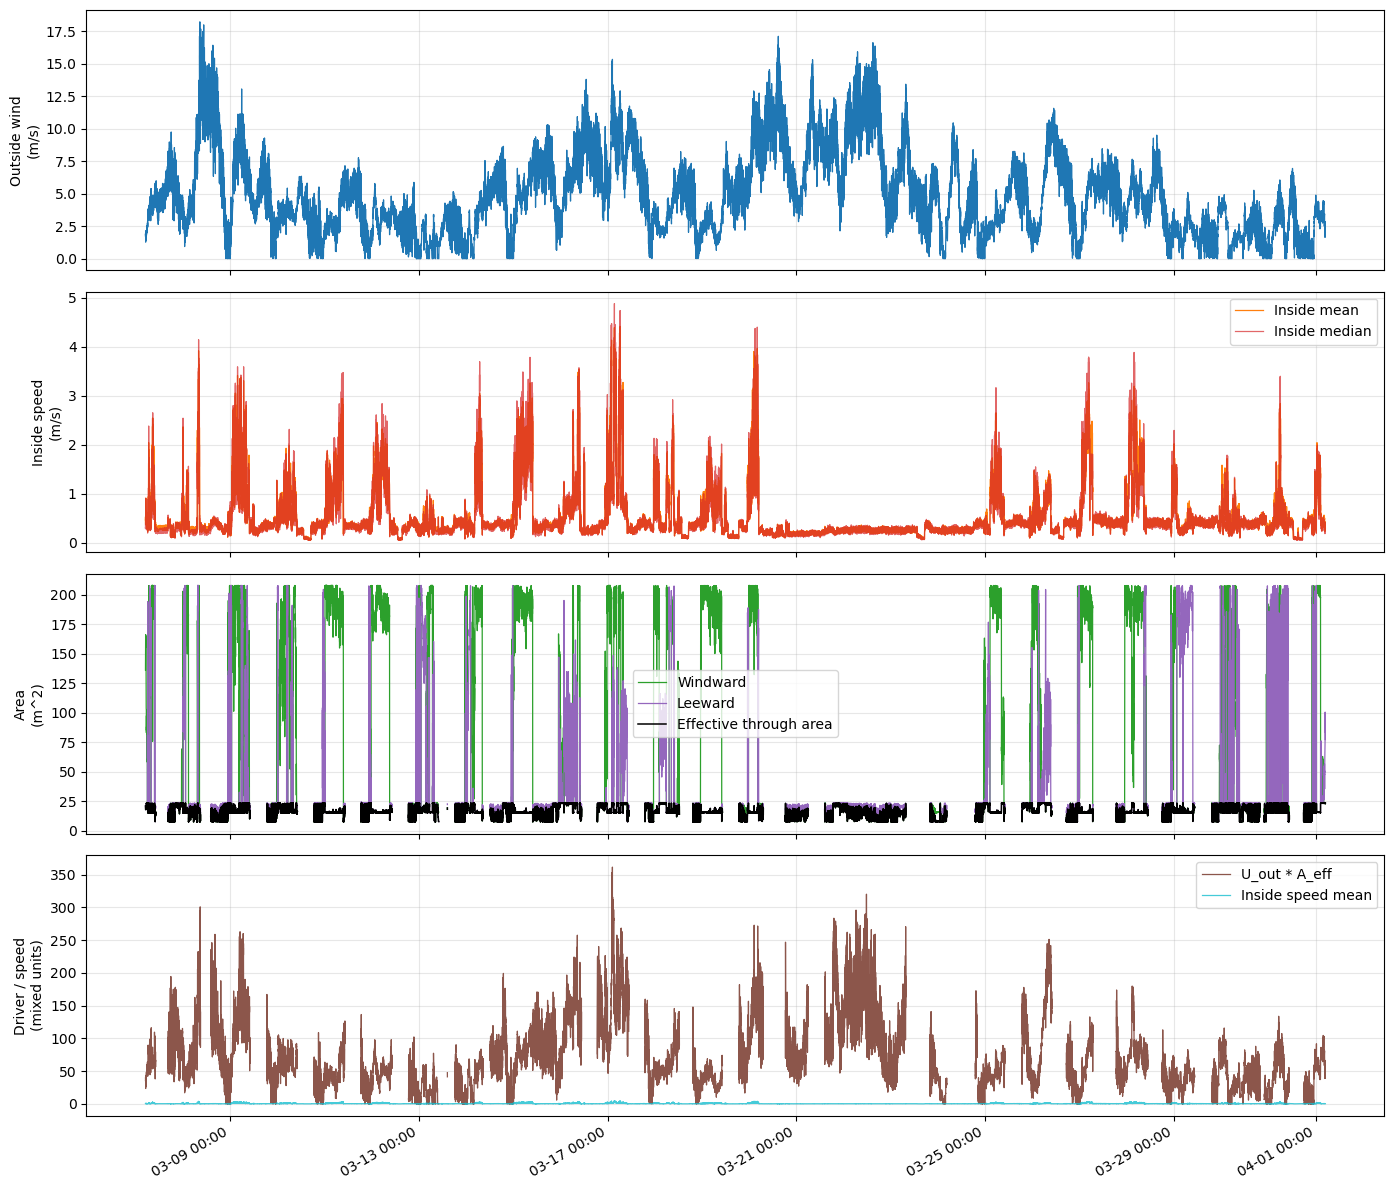

In [25]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(model_df.index, model_df["outside_wind_speed_mps"], color="tab:blue", lw=0.9)
axes[0].set_ylabel("Outside wind\n(m/s)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(model_df.index, model_df["inside_speed_mean_mps"], color="tab:orange", lw=0.9, label="Inside mean")
axes[1].plot(model_df.index, model_df["inside_speed_median_mps"], color="tab:red", lw=0.9, alpha=0.7, label="Inside median")
axes[1].set_ylabel("Inside speed\n(m/s)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(model_df.index, model_df["windward_open_area_m2"], color="tab:green", lw=0.9, label="Windward")
axes[2].plot(model_df.index, model_df["leeward_open_area_m2"], color="tab:purple", lw=0.9, label="Leeward")
axes[2].plot(model_df.index, model_df["effective_through_area_m2"], color="black", lw=1.1, label="Effective through area")
axes[2].set_ylabel("Area\n(m^2)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

axes[3].plot(model_df.index, model_df["outside_driver_m3s_cd1"], color="tab:brown", lw=0.9, label="U_out * A_eff")
if np.isfinite(INTERNAL_REFERENCE_AREA_M2) and INTERNAL_REFERENCE_AREA_M2 > 0:
    axes[3].plot(model_df.index, model_df["inside_flow_proxy_m3s"], color="tab:cyan", lw=0.9, alpha=0.8, label="Inside flow proxy")
    axes[3].set_ylabel("Flow proxy\n(m^3/s)")
else:
    axes[3].plot(model_df.index, model_df["inside_speed_mean_mps"], color="tab:cyan", lw=0.9, alpha=0.8, label="Inside speed mean")
    axes[3].set_ylabel("Driver / speed\n(mixed units)")
axes[3].legend()
axes[3].grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

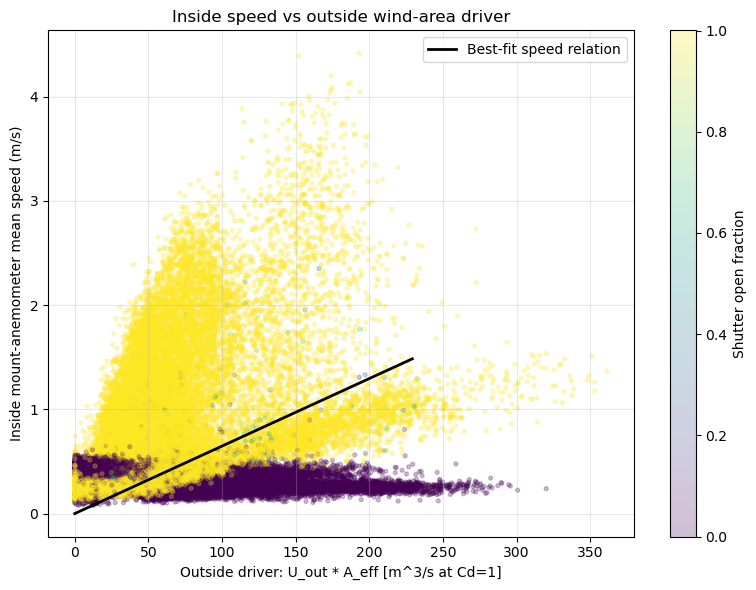

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    fit_df["outside_driver_m3s_cd1"],
    fit_df["inside_speed_mean_mps"],
    s=8,
    alpha=0.25,
    c=fit_df["shutter_open_fraction"],
    cmap="viridis",
)

x_line = np.linspace(0, fit_df["outside_driver_m3s_cd1"].quantile(0.99), 200)
ax.plot(x_line, speed_gain * x_line, color="black", lw=2.0, label="Best-fit speed relation")

ax.set_xlabel("Outside driver: U_out * A_eff [m^3/s at Cd=1]")
ax.set_ylabel("Inside mount-anemometer mean speed (m/s)")
ax.set_title("Inside speed vs outside wind-area driver")
ax.grid(True, alpha=0.3)
ax.legend()
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label("Shutter open fraction")
plt.tight_layout()
plt.show()

In [27]:
summary = pd.Series({
    "samples": len(fit_df),
    "outside_wind_mean_mps": fit_df["outside_wind_speed_mps"].mean(),
    "inside_speed_mean_mps": fit_df["inside_speed_mean_mps"].mean(),
    "effective_area_mean_m2": fit_df["effective_through_area_m2"].mean(),
    "effective_area_p90_m2": fit_df["effective_through_area_m2"].quantile(0.90),
    "outside_driver_mean_m3s_cd1": fit_df["outside_driver_m3s_cd1"].mean(),
    "speed_gain": speed_gain,
    "fitted_discharge_coefficient": fitted_cd,
})
display(summary.to_frame(name="value"))

display(
    fit_df[[
        "outside_wind_speed_mps",
        "outside_wind_dir_deg",
        "dome_azimuth_deg",
        "shutter_open_fraction",
        "windward_open_area_m2",
        "leeward_open_area_m2",
        "effective_through_area_m2",
        "inside_speed_mean_mps",
        "outside_driver_m3s_cd1",
    ]].head(20)
)

,value
samples,49307.000000
outside_wind_mean_mps,4.515972
inside_speed_mean_mps,0.644195
effective_area_mean_m2,16.427104
effective_area_p90_m2,23.147816
outside_driver_mean_m3s_cd1,72.421229
speed_gain,0.006477
fitted_discharge_coefficient,NaN


,outside_wind_speed_mps,outside_wind_dir_deg,dome_azimuth_deg,shutter_open_fraction,windward_open_area_m2,leeward_open_area_m2,effective_through_area_m2,inside_speed_mean_mps,outside_driver_m3s_cd1
2026-03-07 05:00:00+00:00,1.885565,21.127879,328.075989,1.0004,136.333365,20.994154,20.994154,0.462445,39.585847
2026-03-07 05:00:30+00:00,1.800050,19.435000,328.075989,1.0004,140.489123,20.670013,20.670013,0.529398,37.207057
2026-03-07 05:01:00+00:00,1.751400,19.327391,328.075989,1.0004,140.749179,20.648796,20.648796,0.455218,36.164301
2026-03-07 05:01:30+00:00,1.782675,19.129167,328.075989,1.0004,141.226922,20.609521,20.609521,0.479604,36.740078
2026-03-07 05:02:00+00:00,1.907322,19.189999,328.075989,1.0004,141.080488,20.621600,20.621600,0.405644,39.332027
2026-03-07 05:02:30+00:00,1.692325,18.919443,328.075989,1.0004,141.730540,20.567700,20.567700,0.477954,34.807232
2026-03-07 05:03:00+00:00,1.823922,19.866957,328.075989,1.0004,139.440246,20.754447,20.754447,0.453200,37.854488
2026-03-07 05:03:30+00:00,1.816670,18.287826,328.075989,1.0004,143.235767,20.440086,20.440086,0.491380,37.132881
2026-03-07 05:04:00+00:00,1.782675,18.289167,328.075989,1.0004,143.232590,20.440359,20.440359,0.406487,36.438517
2026-03-07 05:04:30+00:00,1.809417,12.866861,328.075989,1.0004,155.420430,19.244362,19.244362,0.364321,34.821083


,louver_type,count,is_rad,static_eff_area_m2,mean_windward_contrib_m2,mean_leeward_contrib_m2
0,1,12,False,20.8,7.965152,4.829785
1,2,10,False,31.6,6.548773,12.912952
2,3,2,False,0.0,0.000000,0.000000
3,4,2,False,0.0,0.000000,0.000000
4,5,2,True,0.0,0.000000,0.000000
5,6,2,True,0.0,0.000000,0.000000
6,7,2,False,0.0,0.000000,0.000000
7,8,2,True,0.0,0.000000,0.000000


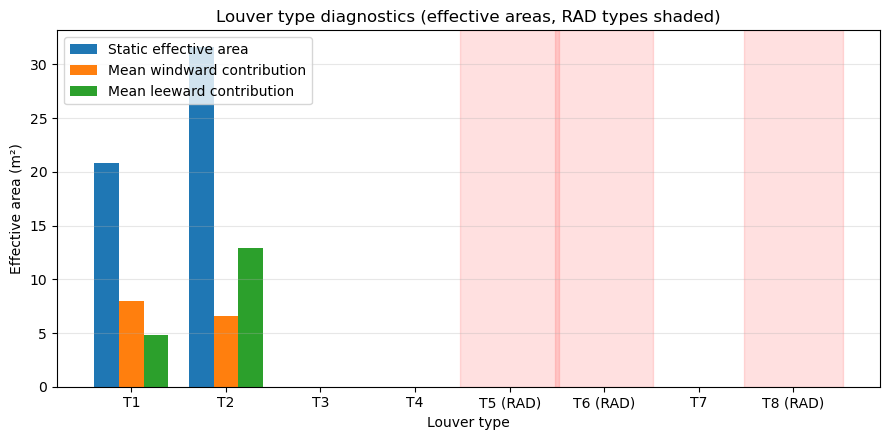

In [28]:
lmap = louver_map.copy()
if "louver_type" not in lmap.columns:
    raise ValueError("louver_type column not found in louver_map.csv.")

lmap["louver_type"] = lmap["louver_type"].astype(int)
lmap["active_area_m2"] = lmap["effective_area_m2"] * lmap["open_fraction"]

theta = np.deg2rad(
    model_df["outside_wind_dir_deg"].to_numpy(dtype=float)[:, None]
    - (model_df["dome_azimuth_deg"].to_numpy(dtype=float)[:, None]
       + lmap["azimuth_dome_deg"].to_numpy(dtype=float)[None, :])
)
proj = np.cos(theta)
ain_mat  = np.clip(proj,  0, None) * lmap["active_area_m2"].to_numpy(dtype=float)[None, :]
aout_mat = np.clip(-proj, 0, None) * lmap["active_area_m2"].to_numpy(dtype=float)[None, :]

type_rows = []
for t in sorted(lmap["louver_type"].unique()):
    mask = lmap["louver_type"].to_numpy() == t
    is_rad_type = lmap.loc[mask, "is_rad"].any()
    type_rows.append({
        "louver_type": int(t),
        "count": int(mask.sum()),
        "is_rad": bool(is_rad_type),
        "static_eff_area_m2": float(lmap.loc[mask, "active_area_m2"].sum()),
        "mean_windward_contrib_m2": float(np.nanmean(ain_mat[:, mask].sum(axis=1))),
        "mean_leeward_contrib_m2": float(np.nanmean(aout_mat[:, mask].sum(axis=1))),
    })

type_diag = pd.DataFrame(type_rows).sort_values("louver_type").reset_index(drop=True)
display(type_diag)

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(type_diag))
w = 0.26
ax.bar(x - w, type_diag["static_eff_area_m2"],       width=w, label="Static effective area")
ax.bar(x,     type_diag["mean_windward_contrib_m2"],  width=w, label="Mean windward contribution")
ax.bar(x + w, type_diag["mean_leeward_contrib_m2"],   width=w, label="Mean leeward contribution")
for xi, row in zip(x, type_diag.itertuples()):
    if row.is_rad:
        ax.axvspan(xi - 2*w, xi + 2*w, alpha=0.12, color="red", label="_RAD" if xi==x[0] else "")
ax.set_xticks(x)
ax.set_xticklabels([f"T{int(t)}" + (" (RAD)" if r else "") for t, r in zip(type_diag["louver_type"], type_diag["is_rad"])])
ax.set_xlabel("Louver type")
ax.set_ylabel("Effective area (m²)")
ax.set_title("Louver type diagnostics (effective areas, RAD types shaded)")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Airflow Efficiency vs Relative Wind Direction

Defines airflow efficiency as the inside-to-outside speed ratio:

`airflow_efficiency = inside_speed_mean_mps / outside_wind_speed_mps`

and plots it against relative wind direction:

`relative_wind_deg = wrap180(outside_wind_dir_deg - (dome_azimuth_deg + SHUTTER_AZIMUTH_OFFSET_DEG))`

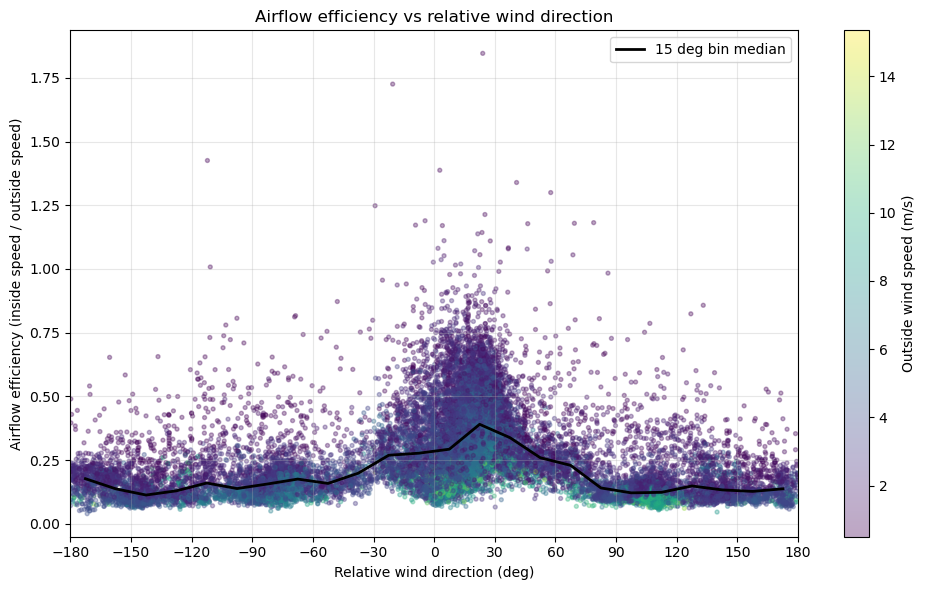

Points used: 23598
Median efficiency: 0.241
P10-P90 efficiency: 0.106 - 0.505


In [29]:
eff_df = model_df.copy()

eff_df["relative_wind_deg"] = wrap180(
    eff_df["outside_wind_dir_deg"] - (eff_df["dome_azimuth_deg"] + SHUTTER_AZIMUTH_OFFSET_DEG)
)
eff_df["airflow_efficiency"] = eff_df["inside_speed_mean_mps"] / eff_df["outside_wind_speed_mps"]

# Filter to physically useful points for stability in the ratio.
eff_df = eff_df[
    np.isfinite(eff_df["relative_wind_deg"])
    & np.isfinite(eff_df["airflow_efficiency"])
    & np.isfinite(eff_df["outside_wind_speed_mps"])
    & np.isfinite(eff_df["shutter_open_fraction"])
    & (eff_df["shutter_open_fraction"] > 0.95)
    & (eff_df["outside_wind_speed_mps"] > 0.5)
    & (eff_df["airflow_efficiency"] >= 0)
    & (eff_df["airflow_efficiency"] <= 3.0)
].copy()

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    eff_df["relative_wind_deg"],
    eff_df["airflow_efficiency"],
    c=eff_df["outside_wind_speed_mps"],
    cmap="viridis",
    s=8,
    alpha=0.35,
)

# Add a binned median trend to make directional structure easier to see.
bins = np.arange(-180, 181, 15)
centers = 0.5 * (bins[:-1] + bins[1:])
bin_idx = np.digitize(eff_df["relative_wind_deg"], bins) - 1
med = [eff_df.loc[bin_idx == i, "airflow_efficiency"].median() for i in range(len(centers))]
ax.plot(centers, med, color="black", lw=2, label="15 deg bin median")

ax.set_xlabel("Relative wind direction (deg)")
ax.set_ylabel("Airflow efficiency (inside speed / outside speed)")
ax.set_title("Airflow efficiency vs relative wind direction")
ax.set_xlim(-180, 180)
ax.set_xticks(np.arange(-180, 181, 30))
ax.grid(True, alpha=0.3)
ax.legend()

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Outside wind speed (m/s)")

plt.tight_layout()
plt.show()

print(f"Points used: {len(eff_df)}")
print(f"Median efficiency: {eff_df['airflow_efficiency'].median():.3f}")
print(f"P10-P90 efficiency: {eff_df['airflow_efficiency'].quantile(0.10):.3f} - {eff_df['airflow_efficiency'].quantile(0.90):.3f}")

## Next Refinements

Useful follow-ups once the notebook is running with your geometry map:

- Replace the static `open_fraction` column with time-dependent louver states if those are available
- Split the model by wind-relative dome angle, not just raw outside speed
- Compare top-ring sensors individually instead of only the across-sensor mean
- Fit separate coefficients for windward-only, shutter-only, and mixed aperture cases
- Add exposure metadata and image-quality metrics if you want to link flow state to observing performance

## Effective Area vs Relative Wind Bearing

Plots the effective louver and shutter area as a function of wind bearing angle relative to the shutter.

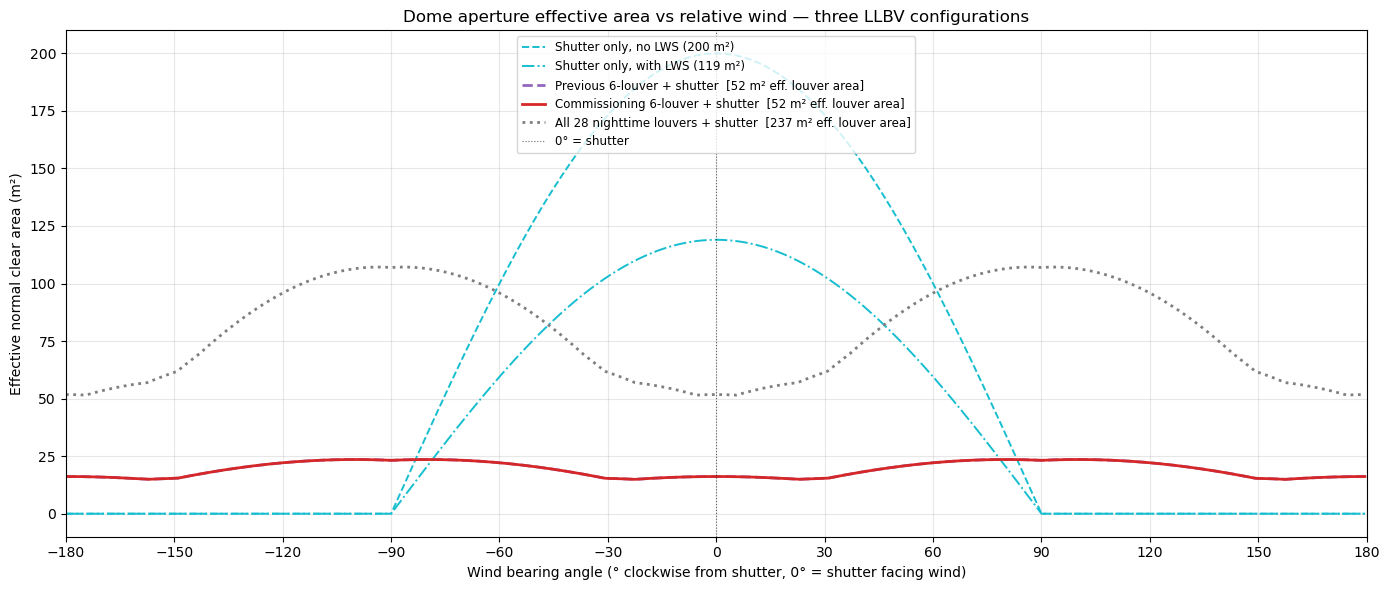

In [30]:
def compute_areas_for_wind_angles(relative_wind_angles, louver_azimuths, louver_areas, shutter_full_open_area_m2):
    """Compute louver windward/leeward and effective through areas for a sweep of wind angles."""
    n = len(relative_wind_angles)
    louver_windward   = np.zeros(n)
    louver_leeward    = np.zeros(n)
    effective_through = np.zeros(n)

    for i, wind_angle in enumerate(relative_wind_angles):
        rel  = wrap180(wind_angle - louver_azimuths)
        proj = np.cos(np.deg2rad(rel))
        lw   = np.sum(louver_areas * np.clip(proj,  0, None))
        ll   = np.sum(louver_areas * np.clip(-proj, 0, None))

        shutter_cos = np.cos(np.deg2rad(wind_angle))
        s_in  = shutter_full_open_area_m2 * max(shutter_cos,  0.0)
        s_out = shutter_full_open_area_m2 * max(-shutter_cos, 0.0)

        louver_windward[i]   = lw
        louver_leeward[i]    = ll
        effective_through[i] = min(lw + s_in, ll + s_out)

    return louver_windward, louver_leeward, effective_through


def make_open_fractions(louver_map, open_ids):
    """Return effective_area_m2 * open_fraction array, with 1.0 for louver_ids in open_ids."""
    fracs = np.where(louver_map["louver_id"].isin(open_ids), 1.0, 0.0)
    return louver_map["effective_area_m2"].to_numpy(dtype=float) * fracs


# Sweep 0–360° then sort into –180…180 for a centred x-axis
wind_angles_raw = np.linspace(0, 360, 721)
sort_idx        = np.argsort(wrap180(wind_angles_raw))
wind_deg        = wrap180(wind_angles_raw)[sort_idx]
wind_angles     = wind_angles_raw[sort_idx]

laz = louver_map["azimuth_dome_deg"].to_numpy(dtype=float)

# ── Three louver configurations ───────────────────────────────────────────────
# Use effective_area_m2 (gross × 0.80) throughout
nighttime_ids     = louver_map.loc[~louver_map["is_rad"], "louver_id"].tolist()
commissioning_ids = louver_map.loc[louver_map["open_fraction"] > 0, "louver_id"].tolist()
previous_ids      = ["B1", "E1", "E2", "H1", "H2", "M1"]

configs = {
    f"Previous 6-louver + shutter\n({', '.join(previous_ids)})": previous_ids,
    f"Commissioning {len(commissioning_ids)}-louver + shutter\n({', '.join(commissioning_ids)})": commissioning_ids,
    f"All {len(nighttime_ids)} nighttime louvers + shutter\n(all non-RAD bays)": nighttime_ids,
}
colors     = ["tab:purple", "tab:red",  "tab:gray"]
linestyles = ["--",          "-",       ":"]

fig, ax = plt.subplots(figsize=(14, 6))

# Shutter-only curves for no-LWS and with-LWS
for s_area, s_label, s_ls in [
    (SHUTTER_FULL_OPEN_AREA_M2_NO_LWS,   f"Shutter only, no LWS ({SHUTTER_FULL_OPEN_AREA_M2_NO_LWS:.0f} m²)",   "--"),
    (SHUTTER_FULL_OPEN_AREA_M2_WITH_LWS, f"Shutter only, with LWS ({SHUTTER_FULL_OPEN_AREA_M2_WITH_LWS:.0f} m²)", "-."),
]:
    shutter_curve = s_area * np.clip(np.cos(np.deg2rad(wind_angles)), 0, None)
    ax.plot(wind_deg, shutter_curve, color="tab:cyan", lw=1.4, ls=s_ls, label=s_label)

# Three louver configurations (all use no-LWS shutter for comparability)
for (label, ids), color, ls in zip(configs.items(), colors, linestyles):
    active_areas = make_open_fractions(louver_map, ids)
    static_total = active_areas.sum()
    _, _, eff = compute_areas_for_wind_angles(
        wind_angles, laz, active_areas, SHUTTER_FULL_OPEN_AREA_M2_NO_LWS)
    short = label.split("\n")[0]
    ax.plot(wind_deg, eff, color=color, lw=2.0, ls=ls,
            label=f"{short}  [{static_total:.0f} m² eff. louver area]")

ax.set_xlabel("Wind bearing angle (° clockwise from shutter, 0° = shutter facing wind)")
ax.set_ylabel("Effective normal clear area (m²)")
ax.set_title("Dome aperture effective area vs relative wind — three LLBV configurations")
ax.set_xlim(-180, 180)
ax.set_xticks(np.arange(-180, 181, 30))
ax.axvline(0,    color="black", lw=0.8, ls=":", alpha=0.6, label="0° = shutter")
ax.axvline(180,  color="gray",  lw=0.8, ls=":", alpha=0.4)
ax.axvline(-180, color="gray",  lw=0.8, ls=":", alpha=0.4)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8.5, loc="upper center")
plt.tight_layout()
plt.show()